# Stellar Surface Gravity (logg) Prediction — PCA + Teff Features

**Improvement over baseline**: adds `log10(teff)` as a 172nd feature + PCA dimensionality reduction.

Baseline (171 color features, no PCA): R²=0.49, RMSE=0.206 dex.

## 1. Imports & Configuration

In [1]:
import pandas as pd

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import warnings
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
sns.set_context("talk")

DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Using device: cpu


## 2. Data Loading & Inspection

In [3]:
PROJECT_ROOT = Path("C:/git_repo/cool-dwarf_stellar_parameter_inference_from_survey_data")
DATA_PATH = PROJECT_ROOT / "data" / "logg_final_df" / "cool_dwarf_catalog_FGKM_consolidated.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
(MODELS_DIR / "logg").mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"\nSpectral type distribution:")
print(df["spectral_type_group"].value_counts().sort_index())
print(f"\nlogg range: {df['logg'].min():.2f} — {df['logg'].max():.2f}")
print(f"teff range: {df['teff'].min():.1f} — {df['teff'].max():.1f}")
df.head()

Dataset shape: (904427, 197)

Spectral type distribution:
spectral_type_group
F    274831
G    578786
K     18889
M     31921
Name: count, dtype: int64

logg range: 3.50 — 5.02
teff range: 3114.1 — 8088.0


,obsid,subclass,gaia_source_id,distance_gaia_pc,teff,logg,A_GG,A_BP,A_RP,A_J,...,COLOR_A_J_A_KS,COLOR_A_J_A_W1,COLOR_A_J_A_W2,COLOR_A_H_A_KS,COLOR_A_H_A_W1,COLOR_A_H_A_W2,COLOR_A_KS_A_W1,COLOR_A_KS_A_W2,COLOR_A_W1_A_W2,spectral_type_group
0,300003054,F0,279692565863680,1197.577725,6512.09,4.105,2.743019,2.867387,2.300888,1.901812,...,0.222598,0.332229,0.241461,-0.019114,0.090517,-0.000251,0.109631,0.018863,-0.090768,F
1,483006140,F0,279692565863680,1197.577725,6549.88,4.120,2.760979,2.956954,2.396033,2.025593,...,0.306546,0.421578,0.381074,0.029463,0.144495,0.103991,0.115032,0.074528,-0.040504,F
2,300014173,F6,492516785395968,592.602005,6131.14,4.276,3.921653,4.337359,3.612836,3.213820,...,0.498134,0.472155,0.377120,0.083556,0.057577,-0.037458,-0.025979,-0.121015,-0.095035,F
3,483006043,F7,492516785395968,592.602005,6123.43,4.270,4.277970,4.636078,3.953510,3.403232,...,0.350874,0.253590,0.357602,0.138743,0.041460,0.145472,-0.097284,0.006728,0.104012,F
4,757516200,F6,617139556505856,1350.264165,6129.88,4.306,3.702365,4.764616,3.579519,3.170527,...,0.012281,0.255204,0.850975,-0.714439,-0.471516,0.124255,0.242923,0.838694,0.595771,F


## 3. Feature & Target Definition (172 features: 171 colors + log10(teff))

In [4]:
# --- 171 photometric color features ---
sorted_mags = [
    'A_BAP', 'A_GSD', 'A_ps_g', 'A_BP', 'A_VAP', 'A_ps_r', 'A_RSD', 'A_RAP',
    'A_GG', 'A_ps_i', 'A_ISD', 'A_RP', 'A_ps_z', 'A_ps_y', 'A_J', 'A_H',
    'A_KS', 'A_W1', 'A_W2'
]

COLOR_COLS = []
for i in range(len(sorted_mags)):
    for j in range(i + 1, len(sorted_mags)):
        COLOR_COLS.append(f'COLOR_{sorted_mags[i]}_{sorted_mags[j]}')

# --- Add log10(teff) as 172nd feature ---
df["log10_teff"] = np.log10(df["teff"].values)

FEATURE_COLS = COLOR_COLS + ["log10_teff"]
TARGET_COL = "logg"

print(f"Number of features: {len(FEATURE_COLS)} (171 colors + log10_teff)")
print(f"Target column: {TARGET_COL}")

X = df[FEATURE_COLS].values.astype(np.float32)
y = df[TARGET_COL].values.astype(np.float32)
spectral_types = df["spectral_type_group"].values

# Sanity checks
assert not np.any(np.isnan(X)), "NaN found in features!"
assert not np.any(np.isinf(X)), "Inf found in features!"
assert not np.any(np.isnan(y)), "NaN found in target!"
print(f"\nNo NaN or Inf in features or target")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")
print(f"  logg range: [{y.min():.4f}, {y.max():.4f}]")
print(f"  log10(teff) range: [{X[:, -1].min():.4f}, {X[:, -1].max():.4f}]")

Number of features: 172 (171 colors + log10_teff)
Target column: logg

No NaN or Inf in features or target
  X shape: (904427, 172)
  y shape: (904427,)
  logg range: [3.5000, 5.0210]
  log10(teff) range: [3.4933, 3.9078]


## 4. Train / Validation / Test Split (70 / 15 / 15)

In [5]:
X_train, X_temp, y_train, y_temp, st_train, st_temp = train_test_split(
    X, y, spectral_types,
    test_size=0.30,
    random_state=SEED,
    stratify=spectral_types,
)

X_val, X_test, y_val, y_test, st_val, st_test = train_test_split(
    X_temp, y_temp, st_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=st_temp,
)

print(f"{'Split':<12} {'Samples':>10}  {'% of total':>10}")
print("-" * 36)
total = len(y)
for name, arr in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(f"{name:<12} {len(arr):>10,}  {100*len(arr)/total:>9.1f}%")

print(f"\nSpectral type proportions (%):")
print(f"{'Type':<6} {'Full':>8} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 40)
for stype in ["F", "G", "K", "M"]:
    full_pct = 100 * np.sum(spectral_types == stype) / len(spectral_types)
    train_pct = 100 * np.sum(st_train == stype) / len(st_train)
    val_pct = 100 * np.sum(st_val == stype) / len(st_val)
    test_pct = 100 * np.sum(st_test == stype) / len(st_test)
    print(f"{stype:<6} {full_pct:>7.1f}% {train_pct:>7.1f}% {val_pct:>7.1f}% {test_pct:>7.1f}%")

Split           Samples  % of total
------------------------------------
Train           633,098       70.0%
Validation      135,664       15.0%
Test            135,665       15.0%

Spectral type proportions (%):
Type       Full    Train      Val     Test
----------------------------------------
F         30.4%    30.4%    30.4%    30.4%
G         64.0%    64.0%    64.0%    64.0%
K          2.1%     2.1%     2.1%     2.1%
M          3.5%     3.5%     3.5%     3.5%


## 5. Data Augmentation (logg-bin-balanced, error-aware)

Bin width: 0.1 dex
Bin edges: 3.50 – 5.10  (16 bins)
Original training size: 633,098
Dropped 2 bin(s), removed 58 samples
Trimmed training size: 633,040

Augmented training size: 1,234,450  (+601,410 synthetic)


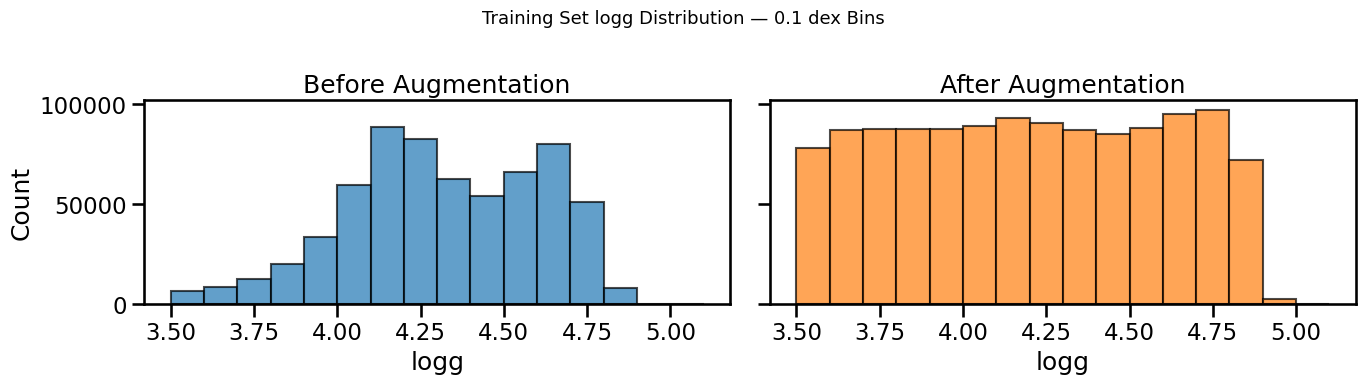

In [6]:
BIN_WIDTH = 0.1
MIN_BIN_SAMPLES = 100

logg_train = y_train

bin_lo = np.floor(logg_train.min() / BIN_WIDTH) * BIN_WIDTH
bin_hi = np.ceil(logg_train.max() / BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH
bin_edges = np.arange(bin_lo, bin_hi, BIN_WIDTH)

bin_ids = np.digitize(logg_train, bin_edges)
unique_bins, bin_counts = np.unique(bin_ids, return_counts=True)

print(f"Bin width: {BIN_WIDTH} dex")
print(f"Bin edges: {bin_edges[0]:.2f} – {bin_edges[-1]:.2f}  ({len(bin_edges)-1} bins)")
print(f"Original training size: {len(y_train):,}")

# Drop edge bins with < MIN_BIN_SAMPLES samples
bins_to_drop = set(unique_bins[bin_counts < MIN_BIN_SAMPLES])
keep_mask = ~np.isin(bin_ids, list(bins_to_drop))
n_dropped = (~keep_mask).sum()

X_train = X_train[keep_mask]
y_train = y_train[keep_mask]
st_train = st_train[keep_mask]
logg_train = logg_train[keep_mask]

print(f"Dropped {len(bins_to_drop)} bin(s), removed {n_dropped:,} samples")
print(f"Trimmed training size: {len(y_train):,}")

# Re-digitize after trimming
bin_ids = np.digitize(logg_train, bin_edges)
unique_bins, bin_counts = np.unique(bin_ids, return_counts=True)
max_count = bin_counts.max()

# Per-bin empirical errors
bin_sigma_features = {}
bin_sigma_logg = {}
for b in unique_bins:
    mask = bin_ids == b
    bin_sigma_features[b] = np.std(X_train[mask], axis=0)  # (172,)
    bin_sigma_logg[b] = np.std(logg_train[mask])

# Save un-augmented copy for scaler+PCA fitting
X_train_orig = X_train.copy()
y_train_orig = y_train.copy()

# Oversample with Gaussian noise injection
rng = np.random.default_rng(SEED)
aug_X_list = []
aug_y_list = []
aug_st_list = []

for b, count in zip(unique_bins, bin_counts):
    if count >= max_count:
        continue
    deficit = max_count - count
    bin_mask = np.where(bin_ids == b)[0]
    src_idx = rng.choice(bin_mask, size=deficit, replace=True)

    noise_X = rng.normal(0.0, bin_sigma_features[b], size=(deficit, X_train.shape[1])).astype(np.float32)
    noise_logg = rng.normal(0.0, bin_sigma_logg[b], size=deficit)
    new_logg = logg_train[src_idx] + noise_logg
    new_logg = np.clip(new_logg, a_min=0.0, a_max=None)

    aug_X_list.append(X_train[src_idx] + noise_X)
    aug_y_list.append(new_logg.astype(np.float32))
    aug_st_list.append(st_train[src_idx])

if aug_X_list:
    X_aug_new = np.concatenate(aug_X_list)
    y_aug_new = np.concatenate(aug_y_list)
    st_aug_new = np.concatenate(aug_st_list)
    n_augmented = len(y_aug_new)
else:
    X_aug_new = np.empty((0, X_train.shape[1]), dtype=np.float32)
    y_aug_new = np.empty(0, dtype=np.float32)
    st_aug_new = np.empty(0, dtype=st_train.dtype)
    n_augmented = 0

X_train_aug = np.concatenate([X_train, X_aug_new])
y_train_aug = np.concatenate([y_train, y_aug_new])
st_train_aug = np.concatenate([st_train, st_aug_new])

# Shuffle
shuffle_idx = rng.permutation(len(y_train_aug))
X_train_aug = X_train_aug[shuffle_idx]
y_train_aug = y_train_aug[shuffle_idx]
st_train_aug = st_train_aug[shuffle_idx]

print(f"\nAugmented training size: {len(y_train_aug):,}  (+{n_augmented:,} synthetic)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
axes[0].hist(y_train_orig, bins=bin_edges, edgecolor='k', alpha=0.7)
axes[0].set_title("Before Augmentation")
axes[0].set_xlabel("logg")
axes[0].set_ylabel("Count")
axes[1].hist(y_train_aug, bins=bin_edges, edgecolor='k', alpha=0.7, color='C1')
axes[1].set_title("After Augmentation")
axes[1].set_xlabel("logg")
fig.suptitle("Training Set logg Distribution — 0.1 dex Bins", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Feature Standardization

Fit on **original (un-augmented) training data only** — no data leakage.

In [7]:
scaler = StandardScaler()
scaler.fit(X_train_orig)

X_train_scaled = scaler.transform(X_train_aug).astype(np.float32)
X_val_scaled   = scaler.transform(X_val).astype(np.float32)
X_test_scaled  = scaler.transform(X_test).astype(np.float32)

# Also scale original (un-augmented) for PCA fitting
X_train_orig_scaled = scaler.transform(X_train_orig).astype(np.float32)

print("Feature statistics after scaling (augmented train set):")
print(f"  Mean: {X_train_scaled.mean(axis=0).mean():.6f}  (should be ~0)")
print(f"  Std:  {X_train_scaled.std(axis=0).mean():.6f}  (should be ~1)")

Feature statistics after scaling (augmented train set):
  Mean: 0.061248  (should be ~0)
  Std:  1.395531  (should be ~1)


## 7. PCA Diagnostics

Fit full PCA on scaled un-augmented training data to examine the eigenspectrum.

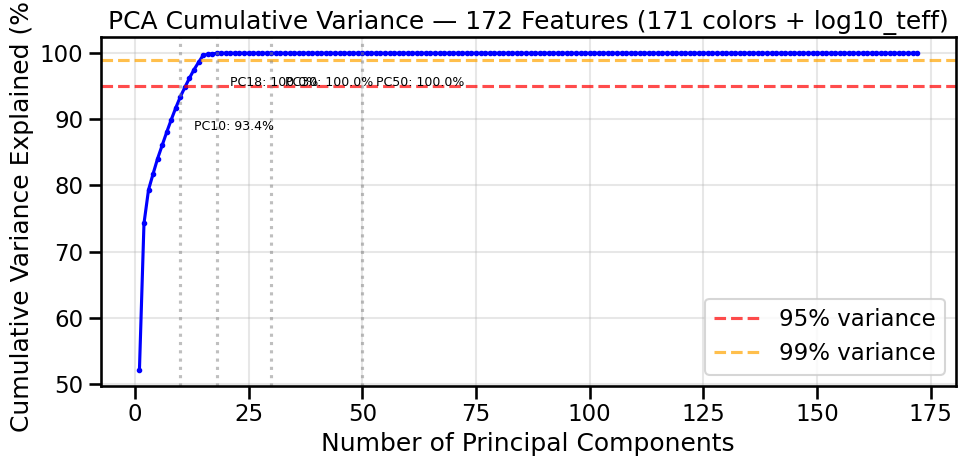


Variance explained at key thresholds:
   10 PCs: 93.42%
   18 PCs: 99.97%
   30 PCs: 100.00%
   50 PCs: 100.00%
  100 PCs: 100.00%
  172 PCs: 100.00%


In [8]:
# Full PCA to examine variance structure
pca_full = PCA(n_components=min(172, X_train_orig_scaled.shape[1]), random_state=SEED)
pca_full.fit(X_train_orig_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumvar) + 1), cumvar, 'b-o', markersize=3)
ax.axhline(95, color='r', linestyle='--', alpha=0.7, label='95% variance')
ax.axhline(99, color='orange', linestyle='--', alpha=0.7, label='99% variance')
for n in [10, 18, 30, 50]:
    if n <= len(cumvar):
        ax.axvline(n, color='gray', linestyle=':', alpha=0.5)
        ax.annotate(f'PC{n}: {cumvar[n-1]:.1f}%', xy=(n, cumvar[n-1]),
                    xytext=(n+3, cumvar[n-1]-5), fontsize=9)
ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative Variance Explained (%)")
ax.set_title("PCA Cumulative Variance — 172 Features (171 colors + log10_teff)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nVariance explained at key thresholds:")
for n in [10, 18, 30, 50, 100, 172]:
    if n <= len(cumvar):
        print(f"  {n:>3} PCs: {cumvar[n-1]:.2f}%")

## 8. PCA Component Sweep

Train a quick model for 20 epochs on a ~100K subsample at each candidate n_components to find the optimal PCA dimensionality.


--- PCA n_components = 18 ---
  Best val MSE: 0.071893  (RMSE: 0.2681 dex)


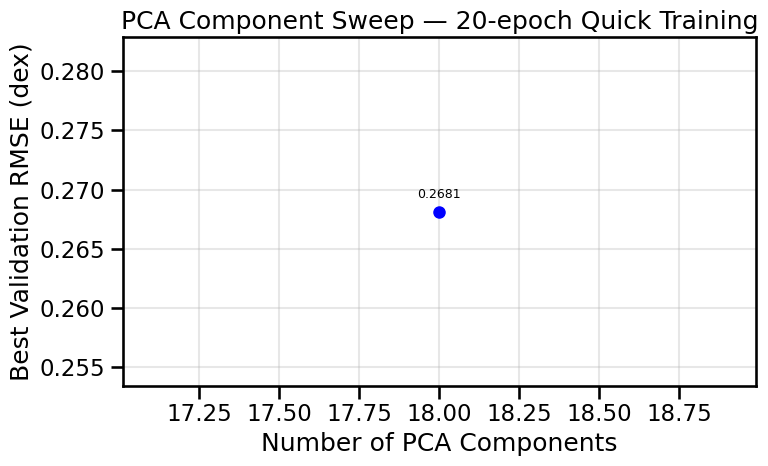


*** Selected n_components = 18 (RMSE = 0.2681 dex) ***


In [16]:
# --- Quick model for PCA sweep ---
class QuickNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )
    def forward(self, x):
        return self.net(x)

# Subsample for speed
N_SUBSAMPLE = min(100_000, len(X_train_scaled))
sub_idx = np.random.RandomState(SEED).choice(len(X_train_scaled), N_SUBSAMPLE, replace=False)
X_sub = X_train_scaled[sub_idx]
y_sub = y_train_aug[sub_idx]

#CANDIDATES = [10, 18, 30, 50, 172]
CANDIDATES = [18]

sweep_results = []

for n_comp in CANDIDATES:
    print(f"\n--- PCA n_components = {n_comp} ---")
    pca_sweep = PCA(n_components=n_comp, random_state=SEED)
    pca_sweep.fit(X_train_orig_scaled)

    X_sub_pca = pca_sweep.transform(X_sub).astype(np.float32)
    X_val_pca = pca_sweep.transform(X_val_scaled).astype(np.float32)

    sub_dataset = TensorDataset(
        torch.tensor(X_sub_pca, dtype=torch.float32),
        torch.tensor(y_sub, dtype=torch.float32).unsqueeze(1)
    )
    val_dataset_pca = TensorDataset(
        torch.tensor(X_val_pca, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
    )
    sub_loader = DataLoader(sub_dataset, batch_size=1024, shuffle=True)
    val_loader_pca = DataLoader(val_dataset_pca, batch_size=2048, shuffle=False)

    torch.manual_seed(SEED)
    quick_model = QuickNet(n_comp).to(DEVICE)
    quick_opt = optim.Adam(quick_model.parameters(), lr=1e-3, weight_decay=1e-5)
    criterion_sweep = nn.MSELoss()

    best_val = float('inf')
    for ep in range(1, 21):
        quick_model.train()
        for Xb, yb in sub_loader:
            quick_opt.zero_grad()
            loss = criterion_sweep(quick_model(Xb), yb)
            loss.backward()
            quick_opt.step()

        quick_model.eval()
        val_loss_total = 0.0
        val_n = 0
        with torch.no_grad():
            for Xb, yb in val_loader_pca:
                val_loss_total += criterion_sweep(quick_model(Xb), yb).item() * len(Xb)
                val_n += len(Xb)
        val_loss = val_loss_total / val_n
        best_val = min(best_val, val_loss)

    rmse = np.sqrt(best_val)
    print(f"  Best val MSE: {best_val:.6f}  (RMSE: {rmse:.4f} dex)")
    sweep_results.append((n_comp, best_val, rmse))

# Plot sweep results
fig, ax = plt.subplots(figsize=(8, 5))
n_comps = [r[0] for r in sweep_results]
val_rmses = [r[2] for r in sweep_results]
ax.plot(n_comps, val_rmses, 'bo-', markersize=8, linewidth=2)
ax.set_xlabel("Number of PCA Components")
ax.set_ylabel("Best Validation RMSE (dex)")
ax.set_title("PCA Component Sweep — 20-epoch Quick Training")
ax.grid(True, alpha=0.3)
for nc, vr in zip(n_comps, val_rmses):
    ax.annotate(f'{vr:.4f}', xy=(nc, vr), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# Select best
best_idx = np.argmin(val_rmses)
N_PCA = n_comps[best_idx]
print(f"\n*** Selected n_components = {N_PCA} (RMSE = {val_rmses[best_idx]:.4f} dex) ***")

## 9. Final PCA Transform

Fit PCA with selected n_components on un-augmented training data, then transform all splits.

In [17]:
pca_final = PCA(n_components=N_PCA, random_state=SEED)
pca_final.fit(X_train_orig_scaled)

X_train_pca = pca_final.transform(X_train_scaled).astype(np.float32)
X_val_pca   = pca_final.transform(X_val_scaled).astype(np.float32)
X_test_pca  = pca_final.transform(X_test_scaled).astype(np.float32)

print(f"PCA: {X_train_scaled.shape[1]} features → {N_PCA} components")
print(f"Variance retained: {100*pca_final.explained_variance_ratio_.sum():.2f}%")
print(f"\nTransformed shapes:")
print(f"  Train (augmented): {X_train_pca.shape}")
print(f"  Validation:        {X_val_pca.shape}")
print(f"  Test:              {X_test_pca.shape}")

PCA: 172 features → 18 components
Variance retained: 99.97%

Transformed shapes:
  Train (augmented): (1234450, 18)
  Validation:        (135664, 18)
  Test:              (135665, 18)


## 10. PyTorch Dataset & DataLoader

In [18]:
class StellarDataset(Dataset):
    def __init__(self, features: np.ndarray, targets: np.ndarray):
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(targets, dtype=torch.float32).unsqueeze(1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = StellarDataset(X_train_pca, y_train_aug)
val_dataset   = StellarDataset(X_val_pca, y_val)
test_dataset  = StellarDataset(X_test_pca, y_test)

BATCH_SIZE = 1024
use_pin_memory = DEVICE.type == "cuda"

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=use_pin_memory)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
                          num_workers=0, pin_memory=use_pin_memory)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
                          num_workers=0, pin_memory=use_pin_memory)

print(f"Train batches: {len(train_loader)}  ({len(train_dataset):,} samples)")
print(f"Val batches:   {len(val_loader)}  ({len(val_dataset):,} samples)")
print(f"Test batches:  {len(test_loader)}  ({len(test_dataset):,} samples)")

X_batch, y_batch = next(iter(train_loader))
print(f"\nSample batch — X: {X_batch.shape}, y: {y_batch.shape}")

Train batches: 1206  (1,234,450 samples)
Val batches:   67  (135,664 samples)
Test batches:  67  (135,665 samples)

Sample batch — X: torch.Size([1024, 18]), y: torch.Size([1024, 1])


## 11. Model Architecture — 4-Layer ANN

`n_pca → 256 → 128 → 64 → 32 → 1` with BatchNorm + Dropout

In [19]:
class StellarLoggNet(nn.Module):
    """4-layer feedforward ANN for logg prediction (PCA + teff features)."""
    def __init__(self, input_dim, dropout=0.15):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.network(x)

model = StellarLoggNet(input_dim=N_PCA).to(DEVICE)
VARIANT_NAME = "pca_teff"

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters: {total_params:,}")
print(f"Input dim: {N_PCA} (PCA components)")

StellarLoggNet(
  (network): Sequential(
    (0): Linear(in_features=18, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.15, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.15, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 49,089
Input dim: 18 (PCA components)


## 12. Training Configuration

In [20]:
criterion = nn.MSELoss()

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

MAX_EPOCHS = 100
EARLY_STOP_PATIENCE = 30

print("Training Configuration:")
print(f"  Loss:           MSE on logg")
print(f"  Optimizer:      Adam (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"  Scheduler:      ReduceLROnPlateau (factor=0.5, patience=5)")
print(f"  Early stopping: patience={EARLY_STOP_PATIENCE} epochs")
print(f"  Max epochs:     {MAX_EPOCHS}")
print(f"  Batch size:     {BATCH_SIZE}")
print(f"  Device:         {DEVICE}")
print(f"  Variant:        {VARIANT_NAME}")

Training Configuration:
  Loss:           MSE on logg
  Optimizer:      Adam (lr=0.001, weight_decay=1e-05)
  Scheduler:      ReduceLROnPlateau (factor=0.5, patience=5)
  Early stopping: patience=30 epochs
  Max epochs:     100
  Batch size:     1024
  Device:         cpu
  Variant:        pca_teff


## 13. Training & Evaluation Functions

In [21]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    n_samples = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
        n_samples += X_batch.size(0)
    return total_loss / n_samples

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    n_samples = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        total_loss += loss.item() * X_batch.size(0)
        n_samples += X_batch.size(0)
    return total_loss / n_samples

## 14. Training Loop

In [22]:
train_losses = []
val_losses = []
lr_history = []

best_val_loss = float("inf")
best_epoch = 0
patience_counter = 0
best_model_state = None

print(f"{'Epoch':>5}  {'Train Loss':>12}  {'Val Loss':>12}  {'LR':>10}  {'Status'}")
print("-" * 65)

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss = evaluate(model, val_loader, criterion, DEVICE)
    current_lr = optimizer.param_groups[0]["lr"]

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    lr_history.append(current_lr)

    scheduler.step(val_loss)

    status = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        status = "* Best"
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"{epoch:>5}  {train_loss:>12.8f}  {val_loss:>12.8f}  {current_lr:>10.2e}  Early stop")
            break

    if epoch % 5 == 0 or status or epoch == 1:
        print(f"{epoch:>5}  {train_loss:>12.8f}  {val_loss:>12.8f}  {current_lr:>10.2e}  {status}")

model.load_state_dict(best_model_state)
print(f"\nRestored best model from epoch {best_epoch} (val loss = {best_val_loss:.8f})")

Epoch    Train Loss      Val Loss          LR  Status
-----------------------------------------------------------------
    1    1.28238158    0.07168391    1.00e-03  * Best
    2    0.09146492    0.06147618    1.00e-03  * Best
    3    0.08264811    0.05761293    1.00e-03  * Best
    4    0.07954690    0.05394219    1.00e-03  * Best
    5    0.07780093    0.05330819    1.00e-03  * Best
    6    0.07660352    0.05323419    1.00e-03  * Best
    7    0.07579573    0.05147589    1.00e-03  * Best
    9    0.07479273    0.05057488    1.00e-03  * Best
   10    0.07443177    0.05260872    1.00e-03  
   13    0.07364703    0.05008433    1.00e-03  * Best
   15    0.07326089    0.05377288    1.00e-03  
   20    0.07168238    0.05235608    5.00e-04  


KeyboardInterrupt: 

## 15. Training Diagnostics

In [ ]:
VARIANT_RESULTS_DIR = RESULTS_DIR / "logg" / VARIANT_NAME
VARIANT_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
epochs_range = range(1, len(train_losses) + 1)
ax.plot(epochs_range, train_losses, label="Train Loss", linewidth=2)
ax.plot(epochs_range, val_losses, label="Val Loss", linewidth=2)
ax.axvline(best_epoch, color="red", linestyle="--", alpha=0.7, label=f"Best epoch ({best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss (logg)")
ax.set_title("Training & Validation Loss")
ax.legend()
ax.set_yscale("log")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs_range, lr_history, linewidth=2, color="green")
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("Learning Rate Schedule")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(VARIANT_RESULTS_DIR / "training_diagnostics.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {VARIANT_RESULTS_DIR / 'training_diagnostics.png'}")

## 16. Test Set Evaluation

In [ ]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        preds = model(X_batch)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y_batch.numpy())

y_pred = np.concatenate(all_preds).flatten()
y_true = np.concatenate(all_targets).flatten()

rmse_dex = np.sqrt(mean_squared_error(y_true, y_pred))
mae_dex = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
median_ae_dex = np.median(np.abs(y_pred - y_true))

print("=" * 50)
print(f"  TEST SET RESULTS — {VARIANT_NAME} variant")
print("=" * 50)
print(f"\n  RMSE:       {rmse_dex:>8.4f} dex")
print(f"  MAE:        {mae_dex:>8.4f} dex")
print(f"  Median AE:  {median_ae_dex:>8.4f} dex")
print(f"  R²:         {r2:>8.5f}")

print(f"\n{'_' * 50}")
print(f"  Per-Spectral-Type Breakdown (dex)")
print(f"{'_' * 50}")
print(f"  {'Type':<6} {'N':>8} {'RMSE':>8} {'MAE':>8} {'MedAE':>8} {'R²':>8}")
print(f"  {'----':<6} {'----':>8} {'----':>8} {'----':>8} {'-----':>8} {'--':>8}")

per_type_metrics = {}
for stype in ["F", "G", "K", "M"]:
    mask = st_test == stype
    if mask.sum() == 0:
        continue
    yt = y_true[mask]
    yp = y_pred[mask]
    st_rmse = np.sqrt(mean_squared_error(yt, yp))
    st_mae = mean_absolute_error(yt, yp)
    st_medae = np.median(np.abs(yp - yt))
    st_r2 = r2_score(yt, yp)
    per_type_metrics[stype] = {"rmse": st_rmse, "mae": st_mae, "r2": st_r2}
    print(f"  {stype:<6} {mask.sum():>8,} {st_rmse:>8.4f} {st_mae:>8.4f} {st_medae:>8.4f} {st_r2:>8.4f}")

## 17. One-to-One Plot

In [ ]:
fig, ax = plt.subplots(figsize=(9, 9))

hb = ax.hexbin(y_true, y_pred, gridsize=200, cmap="inferno", mincnt=1, bins="log")
cb = plt.colorbar(hb, ax=ax, label=r"$\log_{10}$(count)")

lims = [min(y_true.min(), y_pred.min()) - 0.1,
        max(y_true.max(), y_pred.max()) + 0.1]
ax.plot(lims, lims, "r--", linewidth=2, alpha=0.8, label="Perfect prediction")

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("True logg (dex)")
ax.set_ylabel("Predicted logg (dex)")
ax.set_title(f"Predicted vs True logg — {VARIANT_NAME}")
ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=12)

textstr = f"RMSE = {rmse_dex:.4f} dex\nMAE = {mae_dex:.4f} dex\nR² = {r2:.5f}"
ax.text(0.97, 0.03, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment="bottom", horizontalalignment="right",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig(VARIANT_RESULTS_DIR / "one_to_one_plot.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {VARIANT_RESULTS_DIR / 'one_to_one_plot.png'}")

## 18. Residual Plot

In [ ]:
residuals = y_pred - y_true

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
colors_map = {"F": "#1f77b4", "G": "#2ca02c", "K": "#ff7f0e", "M": "#d62728"}
for stype in ["F", "G", "K", "M"]:
    mask = st_test == stype
    ax.scatter(y_true[mask], residuals[mask], alpha=0.05, s=1,
               color=colors_map[stype], label=stype, rasterized=True)
ax.axhline(0, color="black", linestyle="-", linewidth=1)
ax.set_xlabel("True logg (dex)")
ax.set_ylabel("Residual (Predicted - True) [dex]")
ax.set_title(f"Residuals vs True logg — {VARIANT_NAME}")
ax.legend(markerscale=20, fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(residuals, bins=200, edgecolor="none", alpha=0.7, color="steelblue")
ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
ax.axvline(np.mean(residuals), color="orange", linestyle="--", linewidth=1.5,
           label=f"Mean = {np.mean(residuals):.4f} dex")
ax.set_xlabel("Residual (dex)")
ax.set_ylabel("Count")
ax.set_title("Residual Distribution")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(VARIANT_RESULTS_DIR / "residual_plot.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {VARIANT_RESULTS_DIR / 'residual_plot.png'}")

## 19. Save Artifacts

In [ ]:
# Model checkpoint
model_save_path = MODELS_DIR / "logg" / f"stellar_logg_ann_{VARIANT_NAME}_best.pth"
torch.save({
    "model_state_dict": best_model_state,
    "input_dim": N_PCA,
    "n_pca_components": N_PCA,
    "feature_cols": FEATURE_COLS,
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "architecture": str(model),
    "variant": VARIANT_NAME,
}, model_save_path)
print(f"Model saved to {model_save_path}")

# Shared scaler (same across all 3 variants)
scaler_save_path = MODELS_DIR / "logg" / "scaler_pca_teff.pkl"
joblib.dump(scaler, scaler_save_path)
print(f"Scaler saved to {scaler_save_path}")

# Shared PCA transformer
pca_save_path = MODELS_DIR / "logg" / "pca_pca_teff.pkl"
joblib.dump(pca_final, pca_save_path)
print(f"PCA saved to {pca_save_path}")

# Metrics JSON
metrics = {
    "variant": VARIANT_NAME,
    "n_pca_components": N_PCA,
    "rmse_dex": round(float(rmse_dex), 6),
    "mae_dex": round(float(mae_dex), 6),
    "median_ae_dex": round(float(median_ae_dex), 6),
    "r2_score": round(float(r2), 6),
    "best_epoch": best_epoch,
    "total_epochs_run": len(train_losses),
    "n_train_augmented": len(y_train_aug),
    "n_train_original_trimmed": len(y_train_orig),
    "n_augmented_rows": n_augmented,
    "n_val": len(y_val),
    "n_test": len(y_test),
    "n_features_original": len(FEATURE_COLS),
    "per_type_r2": {k: round(v["r2"], 6) for k, v in per_type_metrics.items()},
    "per_type_rmse": {k: round(v["rmse"], 6) for k, v in per_type_metrics.items()},
}
metrics_path = VARIANT_RESULTS_DIR / "test_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"Metrics saved to {metrics_path}")

print(f"\n{'=' * 50}")
print(f"  All artifacts saved — {VARIANT_NAME} variant")
print(f"{'=' * 50}")

## 20. Permutation Importance (on PCA components)

In [ ]:
def calculate_permutation_importance(model, loader, n_features, device):
    model.eval()
    all_X = []
    all_y = []
    with torch.no_grad():
        for Xb, yb in loader:
            all_X.append(Xb)
            all_y.append(yb)

    X_all = torch.cat(all_X).to(device)
    y_all = torch.cat(all_y).cpu().numpy().flatten()

    with torch.no_grad():
        baseline_preds = model(X_all).cpu().numpy().flatten()
    baseline_mse = mean_squared_error(y_all, baseline_preds)
    print(f"Baseline Test MSE: {baseline_mse:.6f}")

    importances = []
    for i in range(n_features):
        X_perm = X_all.clone()
        perm_idx = torch.randperm(X_perm.size(0))
        X_perm[:, i] = X_perm[perm_idx, i]
        with torch.no_grad():
            perm_preds = model(X_perm).cpu().numpy().flatten()
        perm_mse = mean_squared_error(y_all, perm_preds)
        importances.append({
            "Feature": f"PC{i+1}",
            "Importance (MSE Increase)": perm_mse - baseline_mse,
            "Relative Importance": (perm_mse - baseline_mse) / baseline_mse,
        })
    return pd.DataFrame(importances).sort_values("Importance (MSE Increase)", ascending=False)

importance_df = calculate_permutation_importance(model, test_loader, N_PCA, DEVICE)

print(f"\nTop 10 Most Important PCA Components:")
print(importance_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
top_n = min(20, len(importance_df))
top_df = importance_df.head(top_n)
sns.barplot(data=top_df, x="Importance (MSE Increase)", y="Feature", palette="viridis", ax=ax)
ax.set_title(f"PCA Component Importance — {VARIANT_NAME} (Top {top_n})")
ax.set_xlabel("Increase in MSE when component is shuffled")
ax.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(VARIANT_RESULTS_DIR / "permutation_importance.png", dpi=200, bbox_inches="tight")
plt.show()

## 21. Comparison with Baseline

In [ ]:
# Baseline metrics (from stellar_teff_ann_cpu_171_features.ipynb)
baseline = {
    "rmse_dex": 0.20586,
    "r2_score": 0.487838,
    "mae_dex": 0.141182,
    "per_type_r2": {"F": 0.1932, "G": 0.3872, "K": -0.5607, "M": 0.3545},
}

print("=" * 70)
print("  COMPARISON: Baseline (171 colors) vs This Model (PCA + teff)")
print("=" * 70)
print(f"\n  {'Metric':<20} {'Baseline':>12} {'This Model':>12} {'Change':>12}")
print(f"  {'-'*20} {'-'*12} {'-'*12} {'-'*12}")
print(f"  {'RMSE (dex)':<20} {baseline['rmse_dex']:>12.4f} {rmse_dex:>12.4f} {rmse_dex - baseline['rmse_dex']:>+12.4f}")
print(f"  {'MAE (dex)':<20} {baseline['mae_dex']:>12.4f} {mae_dex:>12.4f} {mae_dex - baseline['mae_dex']:>+12.4f}")
print(f"  {'R²':<20} {baseline['r2_score']:>12.5f} {r2:>12.5f} {r2 - baseline['r2_score']:>+12.5f}")

print(f"\n  Per-Spectral-Type R²:")
print(f"  {'Type':<6} {'Baseline':>10} {'This':>10} {'Change':>10}")
print(f"  {'----':<6} {'--------':>10} {'----':>10} {'------':>10}")
for stype in ["F", "G", "K", "M"]:
    bl = baseline["per_type_r2"].get(stype, float('nan'))
    curr = per_type_metrics.get(stype, {}).get("r2", float('nan'))
    print(f"  {stype:<6} {bl:>10.4f} {curr:>10.4f} {curr - bl:>+10.4f}")

target_met = r2 > 0.7
print(f"\n  R² > 0.7 target: {'*** ACHIEVED ***' if target_met else 'NOT YET ACHIEVED'}")
print(f"  (Current R² = {r2:.5f})")